# Introduction to machine learning

In this notebook we will summarize the most important topics and methods in machine learning and basic neuroscience

## Mathematical equipment: Statistics groundwork

### Probability density
Let $X$ be a random variable, with $x \in X$ continually distributed. The variable is described by a probability density $\rho (x)$. Therefore the probabilities are given by the integral:
$$
p(a < x < b) = \int_a^b \mathrm{d}x\,\, \rho(x)
$$
Moreover $\rho(x)$ is normalized with:
$$
\int_{-\infty}^{\infty}\mathrm{dx} \, \rho(x) = 1
$$
For discrete distributions one has to take the sum instead of the integral.

### Expectation value, mean, variance, standard deviation and n-th moment
Let $X$ be a random variable, we define:
\begin{align*}
    & \mu = E(X) = \int_{-\infty}^{\infty}\mathrm{dx} \, \rho(x) x && \textcolor{gray}{\text{expectation value}}\\
    & \braket{x} = \sum_{i=1}^N x_i /N && \textcolor{gray}{\text{discrete mean}}\\
    & \sigma = \sqrt{\int \mathrm{d}x \, (x - \mu)^2\cdot \rho(x)} && \textcolor{gray}{\text{standard deviation}}\\
    & V(X) = (\sigma)^2 = E(X^2) - E(X)^2 && \textcolor{gray}{\text{variance}}\\
    & \mu_n = \braket{X^n} && \textcolor{gray}{\text{n-th moment}}\\
\end{align*}
Here again the integral holds for continuous distributions. The mean consists of the average of a number of $N$ measured events. The law of great numbers states that for $N \rightarrow \infty$ independent draws and finite $\mu$ (and variance) the mean is equal to the expectation value. 

### Conditional probability
The probability for $X = x_i$ under the condition $Y = y_j$ is given by:
$$
p(x_i | y_j) = \frac{p(x_i \land y_j)}{p(y_j)}
$$
where $p(x_i \land y_j)$ is the probability that $x_i$ **and** $y_j$ occur. In general $p(x_i | y_j) \neq p(y_j | x_i)$.
Moreover the following theorems hold:
$$
\begin{align*}
&p(x_i) = \sum_j p(x_i \land y_j)\\
&p(x_i \lor y_j) = p(x_i) + p(y_j) - p(x_i \land y_j)\\
&p(x_i | y_j) = \frac{p(y_j | x_i) \cdot p(x_i)}{p(y_j)} \qquad \quad \textcolor{gray}{\text{Bayes theorem}}
\end{align*}
$$

### Covariance and correlation
Consider the random variables $A,B$. The correlation function $\mathrm{Corr}(AB) \in [-1,1]$ tells us how strongly these two variables are correlated:
\begin{align*}
& \mathrm{Cov}(AB) = \braket{\left( A - \braket{A} \right) \left( B - \braket{B} \right)} = \braket{AB} - \braket{A}\braket{B} && \textcolor{gray}{\text{covariance}}\\
&\mathrm{Corr}(AB) = \frac{\braket{\left( A - \braket{A} \right) \left( B - \braket{B} \right)}}{\sigma_A \sigma_B} = \frac{\braket{AB} - \braket{A}\braket{B}}{\sigma_A \sigma_B} && \textcolor{gray}{\text{correlation}}
\end{align*}
For $\mathrm{Corr}(AB) = 0$ the variables are called uncorrelated. Independence ($\braket{A + B} = \braket{A} + \braket{B}$) implies zero correlation, but zero correlation does not in general imply independence. The covariance is a dimensionful measure of correlation.

The correlation matrix of a set of variables $x_1,\dots, x_N$ is a $N\times N$ matrix defined by its matrix elements (same for covariance matrix) 
$$
C_{ij} = \mathrm{Corr}(x_i,x_j)
$$
Note that diagonal elements are always 1, since a variable always correlates with itself. The information of interest is situated on the off-diagonals, showing relations between different variables.

#### Example
This can easily be implemented in python via numpy. Consider a matrix $m$ with house prices, in the first line of the matrix, and floor spaces in meter squared in the second line. We want to check if these two quantities are correlated:

In [2]:
import numpy as np

# define matrix m
m = np.array([
    [100, 250, 400, 500, 600, 900, 1500, 1550],
    [20, 45, 40, 50, 60, 54, 90, 120]
           ])

# we construct an expectation value function from scratch here (vector input)
def E(x):
    return np.sum(x) / len(x)

## covariance function with arrays as input
def covariance(x,y):
    return E(x*y) - E(x)*E(y)

## and also explicitly the cov matrix
def covariance_matrix(x, y):
    return np.array([
        [covariance(x,x), covariance(x,y)],
        [covariance(y,x), covariance(y,y)]
    ])
    
x=m[0]
y=m[1]

print('We calculated the covariance to be Cov(m) = Cov(x,y) = ')
print(covariance_matrix(x,y))

# now we compare with the numpy function
print('We compare with the result of numpy: Cov(m) = Cov(x,y) = ')
print(np.cov(x,y, bias=True))

We calculated the covariance to be Cov(m) = Cov(x,y) = 
[[262500.        14071.875   ]
 [ 14071.875       857.609375]]
We compare with the result of numpy: Cov(m) = Cov(x,y) = 
[[262500.        14071.875   ]
 [ 14071.875       857.609375]]


So in fact we see that the two parameters are highly correlated. Also one can unse "numpy.corrcoef" to get the normalized covariance matrix via the components:
$$
R_{ij} = \frac{C_{ij}}{\sqrt{C_{ii} C_{jj}}}
$$.

In [3]:
np.corrcoef(m)

array([[1.        , 0.93786981],
       [0.93786981, 1.        ]])


## Important probability distribution

### Binomial distribution
The binomial distribution is a discrete distribution. It describes the distribution of stochastic experiments for which we only have two possible outcomes.


Let $n$ be the number of draws. The probability to get $k$ as outcome, with respective probability $p$ is:
$$
B(k|n,p) = \binom{n}{k} p^k (1-p)^{n-k} = \frac{n!}{(n-k)! \,k!}\, p^k (1-p)^{n-k}
$$
Expectation value: $E(X) = np$\
Second moment: $E(X^2) = np + (n-1)p^2n$\
Variance: $\sigma = np(1-p)$


### Poisson distribution
The Poisson distribution $P_\mu$ is also a discrete probability density. It is described by the expectation value $\mu$:
$$P_\mu (k) = \frac{\mu^k}{k!}e^{-\mu}$$
Expectation value: $\mathrm{E}(X) = \mu$\
Second moment: $\mathrm{E}(X^2) = \mu^2 + \mu$\
Variance $\sigma = \mu$\
The Poisson distribution arises from the Binomial distribution for $n \rightarrow \infty$ and $p \rightarrow 0$ with $\mu = np$.

### Gaussian distribution
The Gaussian distribution arises from the Binomial for large $n$ and $\mu \gg \sigma$. And is the solution of the differential equation:
$$
\frac{\mathrm{d} \rho}{ \mathrm{d}k} = \rho(k) \cdot \left( - \frac{x}{\sigma}\right)
$$
and therefore with $k = \mu + \sigma x$
$$
\frac{\mathrm{d} \rho}{ \mathrm{d}x} = -x \cdot \rho(x) 
$$
This ODE leads to:
$$
\begin{align*}
\rho(x) &= c \cdot \mathrm{e}^{-x^2/2}\\
& = \frac{1}{\sigma \sqrt{2\pi}} \cdot \exp(-(\mu - k )^2 / 2\sigma^2)
\end{align*}
$$


## Estimation

Consider a sample $\mathbf{x} = \{x_1, x_2, \ldots, x_N\}$ drawn independently from a random variable $X$ with probability distribution $P(x)$. Suppose we want to estimate a property $\theta$ of the underlying distribution, such as the expectation value $\theta = E(X)$. The **estimator** $\hat{\theta}$ is a function of the random sample and is therefore itself a random variable. For example,
$$
\hat{\theta} = \frac{1}{N}\sum_{i=1}^N X_i
$$
is the estimator of the expectation value. Once a particular sample $\mathbf{x}$ has been observed, the estimator takes on a specific value,
$$
\hat{\theta}(\mathbf{x}) = \frac{1}{N}\sum_{i=1}^N x_i,
$$
which is called the **estimate**. Thus, $\theta$ is the fixed (but potentially unknown) population property, $\hat{\theta}$ is the random estimator, and $\hat{\theta}(\mathbf{x})$ is the resulting estimate for a particular sample.

## Properties of estimators
- **consistency:** $E(\hat\theta) \to \theta$ and $V(\hat\theta) \to 0$ for $N \to \infty$
- **bias:** $b := E(\hat\theta) - \theta$
- **effciency:** $\varepsilon := \frac{V_\mathrm{min}}{V(\hat\theta)}$ where $V_\mathrm{min}$ is the minimal possible variance 

## Likelihood

The easiest way to understand **likelihood** is to distinguish it from probability. Suppose a random variable depends on an unknown parameter $\theta$ (in example the mean $\mu$). If $\theta$ is known and we ask how likely an observation $x$ is, we consider the **probability**
$$
P(x\mid\theta).
$$

In parameter estimation, we have the opposite situation: a sample $\mathbf{x}$ has been measure, while $\theta$ is unknown. We therefore treat $\mathbf{x}$ as fixed and ask:

> **Which value of $\theta$ makes the observed data most plausible?**

This is the **likelihood**:
$$
L(\mathbf{x};\theta) = P(\mathbf{x}\mid\theta).
$$

The notation emphasizes that $\mathbf{x}$ is fixed while $\theta$ is varied. For independent observations, the probability of observing all of them together is the product and thus also
$$
L(\mathbf{x};\theta)
=
\prod_{i=1}^N P(x_i\mid\theta).
$$

The **maximum likelihood estimator (MLE)** is the parameter value that maximizes this likelihood:
$$
\hat{\theta}_{\mathrm{ML}}
=
\arg\max_\theta L(\mathbf{x};\theta).
$$


### Example: Gaussian measurements

Suppose we measure a quantity $N$ times and obtain $x_1,\ldots,x_N$, where measurement $i$ has uncertainty $\sigma_i$. Assuming Gaussian errors with unknown mean $\mu$,
$$
P(x_i\mid\mu)
=
\frac{1}{\sqrt{2\pi}\sigma_i}
\exp\left(
-\frac{(x_i-\mu)^2}{2\sigma_i^2}
\right).
$$
For independent measurements we get
$$
L(\mathbf{x};\mu)
=
\prod_{i=1}^N P(x_i\mid\mu).
$$
It is easier to maximize the logarithm of the likelihood:
$$
\log L(\mathbf{x};\mu)
=
-\frac12
\sum_{i=1}^N
\frac{(x_i-\mu)^2}{\sigma_i^2}
+\mathrm{const}.
$$
Maximizing this is equivalent to minimizing the weighted squared deviations. Setting the derivative to zero gives
$$
\hat{\mu}_{\mathrm{ML}}
=
\frac{\displaystyle\sum_i x_i/\sigma_i^2}
{\displaystyle\sum_i 1/\sigma_i^2}.
$$

Thus, the maximum likelihood estimate is an **uncertainty-weighted average**: measurements with smaller $\sigma_i$ receive more weight because they are more precise.

In one sentence:

> **Likelihood asks: given the data I observed, which parameter value would have made these data most plausible?**


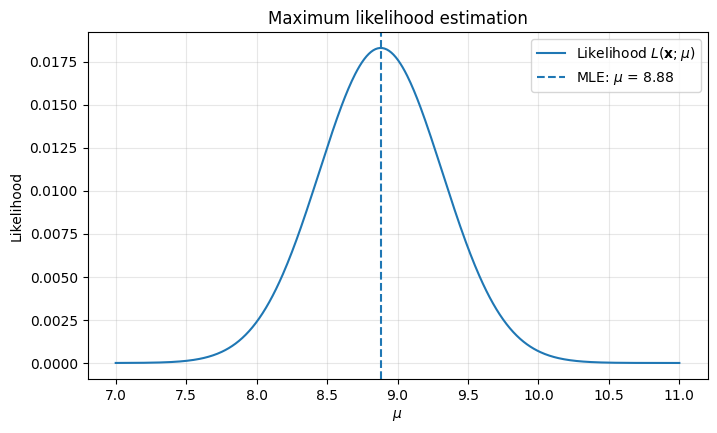

Maximum-likelihood estimate: mu = 8.88


In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Observed measurements and their uncertainties
x = np.array([8.5, 10.0, 10.5])
sigma = np.array([0.5, 1.0, 2.0])
# We assume the data is Gauss distributed

# Try many possible values for the unknown mean
mu_values = np.linspace(7, 11, 500)

# Calculate the likelihood for each possible mu
likelihood = []

for mu in mu_values:
    # Probability of each measurement given this mu
    probabilities = (
        1 / (np.sqrt(2 * np.pi) * sigma)
        * np.exp(-(x - mu)**2 / (2 * sigma**2))
    )

    # Independent measurements -> multiply probabilities
    likelihood.append(np.prod(probabilities))

likelihood = np.array(likelihood)

# Find the maximum-likelihood estimate
mu_ml = mu_values[np.argmax(likelihood)]

# Plot likelihood as a function of mu
plt.figure(figsize=(8, 4.5))
plt.plot(mu_values, likelihood, label="Likelihood $L(\\mathbf{x};\\mu)$")
plt.axvline(mu_ml, linestyle="--",
            label=rf"MLE: $\mu$ = {mu_ml:.2f}")

plt.xlabel(r"$\mu$")
plt.ylabel("Likelihood")
plt.title("Maximum likelihood estimation")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(rf"Maximum-likelihood estimate: mu = {mu_ml:.2f}")

## Implementation of Likelihood fit
TODO

## Chi squared
TODO

## Implementation of chi squared fit
TODO

# Minimization algorithm : Gradient descent optimization

Most deep learning algorithms involve optimization of some sort. Optimization
refers to the task of either minimizing or maximizing some function $f(x)$ by altering
$x$. We usually phrase most optimization problems in terms of minimizing $f(x)$. Maximization may be accomplished via a minimization algorithm by minimizing $-f(x)$. The function we want to minimize or maximize is called the objective function or criterion. When we are minimizing it, we may also call it the cost
function, loss function, or error function [Deep Learning Ian Goodfellow, S. 82].

We can decrease f by moving in the direction of the negative gradient.
This is known as the method of steepest descent or gradient descent. A new point is then given by:
$$
x' = x - \eta \nabla_x f(x)
$$
where $\eta$ is the learning rate (step size) [Deep Learning Ian Goodfellow, S. 85,86].

# Machine learning algorithm: linear regression

Linear regression is a machine learning algorithm, that solves a regression prolem, where the input is connected linearly to the output. 

Consider an input matrix $\textbf{x} \in \mathbb{R}^{n\times p}$. The input consists of $p$ $\textbf{features}$ and each feature has $n$ input values. The output $\textbf{y} \in \mathbb{R}^p$ is then given by: 

$$
\textbf{y} = \textbf{x} \textbf{w} + \textbf{b}
$$
where $\textbf{w} \in \mathbb{R}^p$ is a vector of parameters and $\textbf{b}$ the bias or intercept. We can think of $\textbf{w}$ as a set of $\textbf{weights}$ that determine how each feature affects the output. If a feature receives a positive weight $w_i$, then increasing the value of that feature increases the value of our prediction $\hat{y}$. 

In a more sophisticate model one can absorb the bias in $\textbf{x}$ by adding a row of ones:
$$
\textbf{X} = \begin{pmatrix}
                1 & x_1^1 & \dots & x_1^p\\
                \vdots & \vdots & \ddots & \vdots\\
                1 & x_n^1 & \dots & x_n^p\\
             \end{pmatrix}
$$
If we define a new weight vector is $\textbf{W} \in \mathbb{R}^{p+1}$, where $w_0$ corresponds to the bias, linear regression model becomes
$$
\textbf{y} = \textbf{X} \textbf{W}.
$$
Fitting a linear model to a given data set usually requires estimating the weights such that the error term $\textbf{E} = \textbf{y} − \textbf{X} \textbf{W}$ is minimized. For example, it is common to use the sum of squared errors 
$$
SSE = |\textbf{E}|^2 = |\textbf{y} − \textbf{X} \textbf{W}|^2
$$
as a measure of $\textbf{E}$ for minimization. 

## Implement linear regression for 1 feature

We consider the case where we only have one feature. We will persude the following steps:
- Compute linear regression using scikit-learn
- Examine the error curve 
- Compute linear regression "by hand" using pseudo matrix inverse
- Examine the error curve
- Compare both methods

In [18]:
#import packages
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

#set plot specifications
def plot_secifications(xlabel, ylabel):
    plt.legend()
    plt.grid(alpha=0.3)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

#define the data
def generate_data(true_slope):
    x = np.linspace(0,30,100)
    y = true_slope * x + np.random.randint(20, size=100)
    
    #reshape data
    x = x.reshape(-1,1)
    y = y.reshape(-1,1)
    return x,y

True Intercept: 0
Intercept: [9.79247525]
True Slope: 3.141592653589793
Slope: [3.10076097]


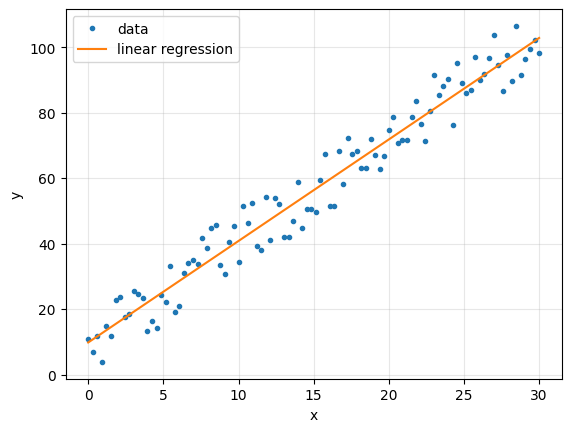

In [19]:
#generate data
true_slope = np.pi
x,y = generate_data(true_slope)

#create a LinearRegression object
lr = LinearRegression()

# fit the model to the data
lr.fit(x, y)

# print the intercept and slope of the fitted line
print('True Intercept:', 0)
print('Intercept:', lr.intercept_)
print('True Slope:', true_slope)
print('Slope:', lr.coef_[0])

#plot the data and fit
plt.plot(x, y, '.', label='data')
plt.plot(x, lr.coef_[0] * x + lr.intercept_, label='linear regression')
plot_secifications('x', 'y')

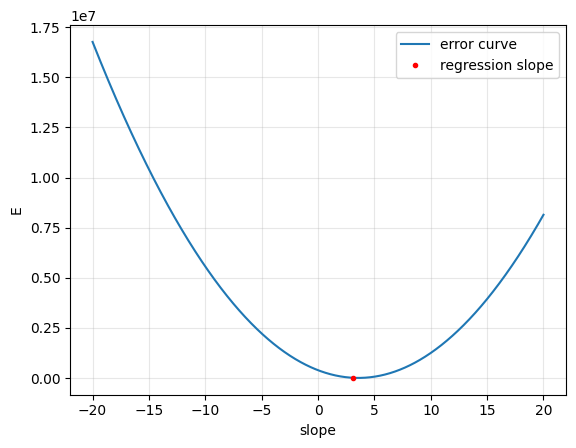

In [29]:
#examine error 
def E(x, y, slope_array):
    error = []
    for slope in slope_array:
        error.append(np.sum((y - x*slope)**2))
    return np.array(error)

def plot_error_curve():
    #print error curve
    slope_array = np.linspace(-20,20,1000)
    plt.plot(slope_array, E(x, y, slope_array), label='error curve')
    #plot the slope from linear regression
    plt.plot(lr.coef_[0], np.sum((y - x*lr.coef_[0])**2), '.', color='red', label='regression slope')
    plot_secifications('slope', 'E')
    
plot_error_curve()

We can see that the regression was sucessfull. The slope lies in the minimum of the error function, that we wanted to minimize.

We now perform the same steps using a by-hand minimization.

True Intercept: 0
Intercept: [9.73980198]
True Slope: 3.141592653589793
Slope: [3.08893919]


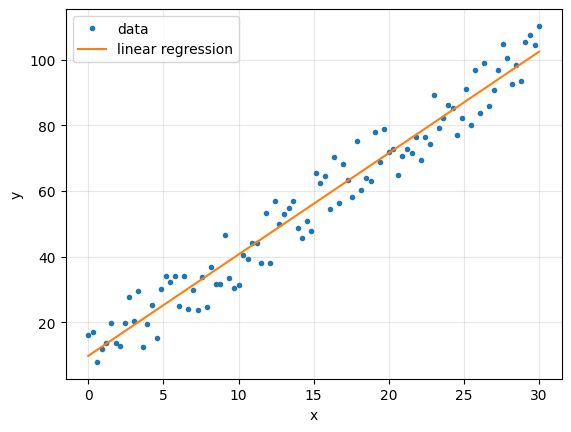

In [25]:
#generate data
true_slope = np.pi
x,y = generate_data(true_slope)

# add a column of ones to X for the intercept term
X_aug = np.hstack((np.ones((x.shape[0], 1)), x))

# compute the weights using the pseudo-inverse method
w = np.linalg.inv(X_aug.T.dot(X_aug)).dot(X_aug.T).dot(y)

# print the intercept and slope of the fitted line
print('True Intercept:', 0)
print('Intercept:', w[0])
print('True Slope:', true_slope)
print('Slope:', w[1])

#plot the data and fit
plt.plot(x, y, '.', label='data')
plt.plot(x, w[1] * x + w[0], label='linear regression')
plot_secifications('x', 'y')

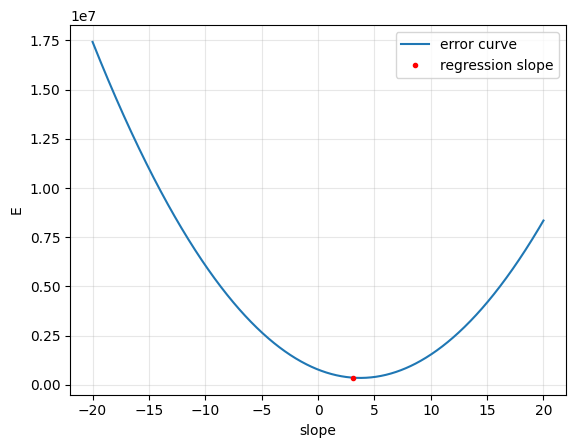

In [32]:
#examine error 
def E(x, y, slope_array):
    error = []
    for slope in slope_array:
        error.append(np.sum((y - x*slope)**2))
    return np.array(error)

def plot_error_curve():
    #print error curve
    slope_array = np.linspace(-20,20,1000)
    plt.plot(slope_array, E(X_aug, y, slope_array), label='error curve')
    #plot the slope from linear regression
    plt.plot(w[1], np.sum((y - w[1])**2), '.', color='red', label='regression slope')
    plot_secifications('slope', 'E')
    
plot_error_curve()

The difference between the two methods lies in the implementation details. Scikit-learn's LinearRegression uses the method of least squares, which is a common approach for solving linear regression problems. It involves setting up and solving a system of linear equations to obtain the optimal weights.

The pseudo-inverse method, on the other hand, is a matrix-based approach that involves computing the Moore-Penrose pseudo-inverse of the input matrix and using it to solve for the weights. This method is particularly useful when the input matrix is not full rank, meaning it does not have an inverse. In such cases, the pseudo-inverse provides a way to obtain a solution that minimizes the sum of squared errors.

Both methods will produce the same result for a given linear regression problem, but the pseudo-inverse method can be more computationally efficient in some cases, particularly when the input matrix is not full rank. Scikit-learn's LinearRegression is a more general method that can be applied to a variety of linear regression problems, and it also includes additional features such as regularization options and methods for handling categorical variables [chatGPT].

# Digit recognition with MNIST

In the following we implement a digit recognition (machine learning) algorithm taken from https://github.com/salah3x/nn-and-dl/blob/master/network.py.

In the following we use the stochastic gradient descent learning
algorithm for a feedforward neural network.  Gradients are calculated
using backpropagation.  

In [ ]:
# Import packages
import random
import numpy as np

Some information about the following variables and functions:
- *Layer structure*: The list ``sizes`` contains the number of neurons in the
respective layers of the network.  For example, if the list
was [2, 3, 1] then it would be a three-layer network, with the
first layer containing 2 neurons, the second layer 3 neurons,
and the third layer 1 neuron.  The biases and weights for the
network are initialized randomly, using a Gaussian
distribution with mean 0, and variance 1.  Note that the first
layer is assumed to be an input layer, and by convention we
won't set any biases for those neurons, since biases are only
ever used in computing the outputs from later layers.

- *SGD*: We train the neural network using mini-batch stochastic
gradient descent.  The ``training_data`` is a list of tuples
``(x, y)`` representing the training inputs and the desired
outputs.  The other non-optional parameters are
self-explanatory.  If ``test_data`` is provided then the
network will be evaluated against the test data after each
epoch, and partial progress printed out.  This is useful for
tracking progress, but slows things down substantially.

In [1]:
# Define the network
class Network(object):

    def __init__(self, sizes):
        self.num_layers = len(sizes)
        self.sizes = sizes
        self.biases = [np.random.randn(y, 1) for y in sizes[1:]]
        self.weights = [np.random.randn(y, x) for x, y in zip(sizes[:-1], sizes[1:])]

    # Feedforward network means that the connections of the nodes do not form a cycle
    def feedforward(self, a):
        # Return the output of the network if ``a`` is input
        for b, w in zip(self.biases, self.weights):
            a = sigmoid(np.dot(w, a)+b)
        return a

    def SGD(self, training_data, epochs, mini_batch_size, eta,
            test_data=None):
        n = len(training_data)
        for j in range(epochs):
            random.shuffle(training_data)
            mini_batches = [training_data[k:k+mini_batch_size] for k in range(0, n, mini_batch_size)]
            for mini_batch in mini_batches:
                self.update_mini_batch(mini_batch, eta)
            if test_data:
                print("Epoch {0}: {1} / {2}".format(j, self.evaluate(test_data), len(test_data)))
            else:
                print("Epoch {0} complete".format(j))

    def update_mini_batch(self, mini_batch, eta):
        """Update the network's weights and biases by applying
        gradient descent using backpropagation to a single mini batch.
        The ``mini_batch`` is a list of tuples ``(x, y)``, and ``eta``
        is the learning rate."""
        nabla_b = [np.zeros(b.shape) for b in self.biases]
        nabla_w = [np.zeros(w.shape) for w in self.weights]
        for x, y in mini_batch:
            delta_nabla_b, delta_nabla_w = self.backprop(x, y)
            nabla_b = [nb+dnb for nb, dnb in zip(nabla_b, delta_nabla_b)]
            nabla_w = [nw+dnw for nw, dnw in zip(nabla_w, delta_nabla_w)]
        self.weights = [w-(eta/len(mini_batch))*nw for w, nw in zip(self.weights, nabla_w)]
        self.biases = [b-(eta/len(mini_batch))*nb for b, nb in zip(self.biases, nabla_b)]

    def backprop(self, x, y):
        """Return a tuple ``(nabla_b, nabla_w)`` representing the
        gradient for the cost function C_x.  ``nabla_b`` and
        ``nabla_w`` are layer-by-layer lists of numpy arrays, similar
        to ``self.biases`` and ``self.weights``."""
        nabla_b = [np.zeros(b.shape) for b in self.biases]
        nabla_w = [np.zeros(w.shape) for w in self.weights]
        # feedforward
        activation = x
        activations = [x] # list to store all the activations, layer by layer
        zs = [] # list to store all the z vectors, layer by layer
        for b, w in zip(self.biases, self.weights):
            z = np.dot(w, activation)+b
            zs.append(z)
            activation = sigmoid(z)
            activations.append(activation)
        # backward pass
        delta = self.cost_derivative(activations[-1], y) * sigmoid_prime(zs[-1])
        nabla_b[-1] = delta
        nabla_w[-1] = np.dot(delta, activations[-2].transpose())
        # Note that the variable l in the loop below is used a little
        # differently to the notation in Chapter 2 of the book.  Here,
        # l = 1 means the last layer of neurons, l = 2 is the
        # second-last layer, and so on.  It's a renumbering of the
        # scheme in the book, used here to take advantage of the fact
        # that Python can use negative indices in lists.
        for l in range(2, self.num_layers):
            z = zs[-l]
            sp = sigmoid_prime(z)
            delta = np.dot(self.weights[-l+1].transpose(), delta) * sp
            nabla_b[-l] = delta
            nabla_w[-l] = np.dot(delta, activations[-l-1].transpose())
        return (nabla_b, nabla_w)

    def evaluate(self, test_data):
        """Return the number of test inputs for which the neural
        network outputs the correct result. Note that the neural
        network's output is assumed to be the index of whichever
        neuron in the final layer has the highest activation."""
        test_results = [(np.argmax(self.feedforward(x)), y) for (x, y) in test_data]
        return sum(int(x == y) for (x, y) in test_results)

    def cost_derivative(self, output_activations, y):
        """Return the vector of partial derivatives \partial C_x /
        \partial a for the output activations."""
        return (output_activations-y)

#### Miscellaneous functions
def sigmoid(z):
    """The sigmoid function."""
    return 1.0/(1.0+np.exp(-z))

def sigmoid_prime(z):
    """Derivative of the sigmoid function."""
    return sigmoid(z)*(1-sigmoid(z))

## Train a neural network against the MNIST dataset
if __name__ == "__main__":
    import mnist_loader

    training_data, validation_data, test_data = mnist_loader.load_data_wrapper()
    net = Network([784, 30, 10])
    net.SGD(training_data, 30, 10, 3.0, test_data=test_data)

ModuleNotFoundError: No module named 'mnist_loader'

# Neuroscience

## Vocabular
### Dendrites, soma, axon
A typical neuron can be divided into three functionally distinct parts, called dendrites, the soma, and the axon. Roughly speaking, the dendrites play the role of the “input
device” that collects signals from other neurons and transmits them to the soma. The soma
is the “central processing unit” that performs an important nonlinear processing step: if
the total input arriving at the soma exceeds a certain threshold, then an output signal is
generated. The output signal is taken over by the “output device,” the axon, which delivers
the signal to other neurons [S.4 Gerstner].

### Synapse
The junction between two neurons is called synapse.

Let us suppose that a neuron sends
a signal across a synapse. It is common to refer to the sending neuron as the presynaptic
cell and to the receiving neuron as the postsynaptic cell [S.4 Gerstner].

The coupling strength between a presynaptic neuron $j$ and a postsynaptic neuron $i$ is called **synaptic weight** and denoted as $w_{ij}$. The process of parameter adaptation is called **learning** and the
procedure for adjusting the weights is referred to as a **learning rule** [S.491 Gerstner].

### Spikes / action potential
The neuronal signals consist of short electrical pulses, so-called action potentials or spikes, have an amplitude of about 100 mV and
typically a duration of 1–2 ms. The form of the pulse does not change as the action potential
propagates along the axon. Since isolated spikes of a given neuron look alike, the form of the action
potential does not carry any information. Rather, it is the number and the timing of spikes
which matter [S.5 Gerstner].

### Spike train
A chain of action potentials emitted by a single neuron is called
a spike train – a sequence of stereotyped events which occur at regular or irregular intervals. Action potentials in a spike train are usually well separated [S.5 Gerstner].


## Models

## Rate based models
In the following we will use the letter $u$ to denote a presynaptic firing rate, and $v$ to denote a postsynaptic rate. Note that $v$ is used here to denote a firing rate, not a membrane potential. In addition, we use
these two letters to distinguish input and output firing rates in network
models. The generated synaptic current is then given by 
$$
I_s = w \cdot u
$$
where $w$ denotes the **weight**.
When we consider multiple input or output neurons, we use vectors $\textbf{u}$ and $\textbf{v}$ to
represent their firing rates collectively, with the components of these vectors representing the firing rates of the individual input and output units [S.288 Abott].

We now assume that the output is given by some activation function $F$ (like for e.g. the sigmoid): $v = F(I_s(t))$

### Synaptic plasticity
*Definition:* In experimental neuroscience, changes of the synaptic strength (weights)
are called synaptic plasticity [S.491 Gerstner].

### Spike-timing-dependent plasticity (STDP)
Consider a presynaptic neuron (j) and a postsynaptic neuron (i) that are forced to fire spikes at times $t_i^f, t_j^f$. The resulting change in the synaptic strength turns out to be a function of  $t_j^f - t_i^f$. This is called Spike-timing-dependent plasticity (STDP) [S.491 Gerstner].

### Triplet model
Experiments have shown that an increase in the frequency of spike trains leads to an increase in potential [S.502 Gerstner]

One simple approach to modeling STDP which addresses the issues of frequency dependence is the triplet rule.

### Weight perturbation

Consider a network getting input over a trial duration $T$ and generating output. Time is split into discrete steps, indexed by $t = 1, \dots , T$. At the end of a trial, it receives a scalar
error feedback $E$ (sum of the squared errors) about its performance.
To quantitatively introduce the learning rules, we consider a neuron $i$, which may be part of a larger network.
It generates in the $t$-th time bin an output firing rate $z_{it}$,
in response to the firing rates $r_{jt}$ of its $N$ presynaptic
neurons [paper, Paul Züge]
$$
z_{it} = f \left(\sum_{j=1}^N w_{ij} \cdot r_{jt} \right) 
$$
Here $f$ is the activation function (example sigmoid). 

Weight perturbation now happens when we add a (for example gaussian distributed with mean 0 and standard deviation $\sigma$) noise $\epsilon$ to the weights at the beginning of each trial:
$$
z_{it} = f \left(\sum_{j=1}^N \left[w_{ij} + \epsilon_{ij} \right]\cdot r_{jt} \right) 
$$
The update rule is chosen to be:
$$
\Delta w_{ij} = -\frac{\eta}{\sigma^2} (E'-E)\cdot \epsilon_{ij}
$$
where $\eta$ is the learning rate, $E'$ is the error of the perturbed trial and $E$ is the error of the unperturbed trial.

